## 2.2 图像预处理 - 图像增强

#### 1. 什么是图像增强

##### 1.1 图像增强的定义
图像增强（Data Augmentation）指的是：

在不改变样本本质标签的前提下，对原始图像进行合理变换，从而生成更多“不同版本”的训练样本。

例如，一张“猫”的图片经过：
* 随机裁剪
* 左右翻转
* 轻微旋转
* 亮度变化

之后，虽然图像样子有些变化，但它本质上还是“猫”。

所以标签通常不需要改变。

##### 1.2 为什么要做图像增强
图像增强在 CNN 中非常重要，主要有几个作用：
* 增加训练样本的多样性
* 缓解训练数据不足的问题
* 减少过拟合
    * 因为增强让训练集“看起来更多样”了。
    * 模型不能只死记某一张固定图，而必须学会更稳定、更本质的特征。
* 提高模型的泛化能力
* 让模型适应现实中的位置、角度、亮度变化

所以图像增强常被视为一种非常有效的正则化思路。

它不是直接改模型结构，而是从数据角度减少过拟合。

##### 1.3 图像增强和普通预处理的区别
这两个概念很容易混淆。⭐

普通预处理 更强调：
* 统一输入格式
* 让图像能顺利进入模型
* 例如：
    * resize
    * 转 tensor
    * 归一化
    * 标准化
    * dtype和shape处理

图像增强 更强调：
* 在训练阶段人为制造合理变化
* 提高模型鲁棒性和泛化能力
* 例如：
    * random crop
    * random flip
    * random rotation
    * color jitter
    * add noise

📌 所以现在这一节学的重点，不是“图像怎么统一尺寸”，而是“如何让训练样本更丰富”。

#### 2. 图像增强的核心思想

##### 2.1 不改变“类别本质”
图像增强最重要的前提是：

变换之后，图像的语义不能被破坏。

例如：
* 猫左右翻转后还是猫 ✅
* 人脸轻微旋转后还是同一个人 ✅
* 数字“6”如果随便旋转 180°，可能就不再适合原标签了 ⚠️

所以图像增强并不是“操作越多越好”，而是要看任务本身。

##### 2.2 模型真正要学的是什么
我们希望模型学到的是：
* 这个目标长什么样
* 这个目标有哪些稳定特征
* 不同环境下仍然能识别它

而不是学到一些不该依赖的东西，例如：
* 目标一定在正中间
* 一定朝向左边
* 一定亮度正常
* 一定背景干净

所以增强的本质，就是帮助模型摆脱对“偶然条件”的依赖。

##### 2.3 图像增强为什么只主要用于训练集
因为训练集的目标是：

`帮助模型学习。`

所以训练集可以加入很多随机变化，让模型更强。

而验证集、测试集的目标是：

公平评估模型。

📌 这个原则一定要记住：
```
训练集可以增强，验证集 / 测试集一般不做随机增强。
否则每次评估输入都不同，结果会不稳定，也不公平。
```

#### 3. 图像增强中的任务适配思想

##### 3.1 不是所有增强都适合所有任务
这是这一节最重要的思维之一。⭐

必须考虑：
* 我的任务是什么？
* 图像有什么特点？
* 标签是否会因变换而改变？

##### 3.2 例子：自然图像分类
例如猫狗分类：
* 随机裁剪 ✅
* 水平翻转 ✅
* 轻微旋转 ✅
* 颜色抖动 ✅

##### 3.3 例子：手写数字识别
例如 MNIST：
* 轻微平移 ✅
* 轻微旋转 ✅
* 左右翻转 ❌
* 上下翻转 ❌
* 大角度旋转 ⚠️

因为数字方向本身会影响含义。

##### 3.4 例子：医学图像
例如 MRI / CT：
* 是否翻转要非常谨慎 ⚠️
* 颜色抖动通常不适合灰度医学图像 ⚠️
* 加噪声要谨慎，不能破坏病灶信息 ⚠️
* 轻微裁剪、轻微旋转是否可用，要看具体任务和医学语义

📌 所以图像增强不是“固定模板”，而是“任务驱动”。

#### 4. 调整图像大小 Resize

##### 4.1 为什么要 resize
不同来源的图像，尺寸通常不一样，例如：
* 一张是 300 × 500
* 一张是 1024 × 768
* 一张是 28 × 28

而 CNN 在训练时，通常要求同一个 batch 中的图片形状一致。

所以最常见的做法就是：先统一尺寸。

##### 4.2 resize 的本质是什么
resize 的本质是：

把原图重新采样，变成新的高宽尺寸。

例如：
* (500, 300, 3) → (224, 224, 3)
* (28, 28) → (32, 32)

这一步不是简单“裁掉”或者“压缩文字说明”，而是通过插值算法重新生成新的像素值。

##### 4.3 resize 的影响
resize 很常见，但也有代价：
* 缩小太多，可能丢失细节
* 放大太多，可能模糊
* 长宽比处理不好，可能导致图像变形

所以在选择输入尺寸时，要结合任务特点。

例如：
* MNIST 这种简单数字图像，28 × 28 就够了
* 自然图像分类常见 224 × 224
* 医学图像有时需要更高分辨率

##### 4.3 PyTorch 中常见写法
如果后面使用 torchvision.transforms，常见是：
``` python
from torchvision import transforms

transform = transforms.Resize((224, 224))
```
这里的 (224, 224) 表示：
* 高 224
* 宽 224


#### 5. 裁剪 Crop

##### 5.1 什么是裁剪
裁剪（Crop）就是：
* 从原始图像中截取出一部分区域。
* 它不是缩放，而是“保留一块，舍弃其余部分”

##### 5.2 为什么裁剪可以作为增强
因为现实中的目标不一定总是完整、居中、大小固定。

通过裁剪，模型可以学会：
* 目标不在正中间也能识别
* 只看到目标的一部分也能提取特征
* 不要过度依赖背景

##### 5.3 常见裁剪类型
**（1）随机裁剪 Random Crop**

每次从不同位置随机截取一块区域。

作用：
* 增加训练样本变化
* 提高模型对目标位置变化的适应能力

例如，一张猫图：
* 第一次裁到猫脸
* 第二次裁到猫身体
* 第三次裁到猫偏左的区域

虽然不同，但都仍然可能是有效训练样本。

**（2）随机缩放后裁剪 Random Resized Crop**

这是更常见的一种增强方式。

它通常会先随机选择图像中的一块区域，再缩放成模型要求的固定尺寸。

作用：
* 同时模拟目标大小变化和位置变化
* 既增强多样性，又保证输出尺寸统一

📌 这类操作在图像分类中非常常见。

##### 5.4 裁剪的风险
裁剪虽然有用，但也有边界：
* 裁得太狠，主体可能被裁没了
* 关键信息可能丢失
* 小目标任务中尤其危险

##### 5.5 torchvision.transforms 中的简单示例
在 torchvision.transforms 中，裁剪增强常见写法如下：
``` python
from torchvision import transforms

transform_crop = transforms.RandomCrop(size=(224, 224))

transform_resized_crop = transforms.RandomResizedCrop(
    size=(224, 224),
    scale=(0.8, 1.0),   # 随机裁剪区域占原图面积比例
    ratio=(0.9, 1.1)    # 随机长宽比范围
)
```
说明：
* RandomCrop：直接随机截取固定大小区域
* RandomResizedCrop：先随机裁一块，再缩放到指定大小
* 在实际分类任务中，RandomResizedCrop 更常用

#### 6. 翻转 Flip

##### 6.1 什么是翻转
翻转（Flip）就是把图像做镜像变换，常见包括：
* 左右翻转（水平翻转）
* 上下翻转（垂直翻转）

##### 6.2 水平翻转 Horizontal Flip
这是最常见的增强之一。

例如：
* 猫朝左 → 翻转后猫朝右
* 车头朝左 → 翻转后朝右

作用：
* 让模型不要依赖固定朝向
* 增强左右方向变化下的鲁棒性

📌 很多自然图像任务中，水平翻转都很常用。

##### 6.3 垂直翻转 Vertical Flip
就是上下颠倒。

例如：
* 天在上、地在下 → 翻转后天在下、地在上

这种增强不是所有任务都合适。

因为很多现实图像有明确上下语义：
* 人脸上下颠倒不自然
* 风景图上下颠倒往往不合理

所以垂直翻转要谨慎使用。

##### 6.4 为什么翻转有效
因为它让模型明白：
* 目标朝左或朝右，本质上可能仍是同一类
* 不要死记某个固定方向

##### 6.5 什么场景不适合翻转
翻转不是万能的，下面一些场景要谨慎：
* 文字识别：翻转后文字就变了
* 数字识别：某些数字翻转后语义可能变化
* 医学图像：左右方向可能有重要含义
* 地图、交通标志等方向敏感任务

📌 所以增强前一定要问：

这张图翻转后，标签还成立吗？

##### 6.6 torchvision.transforms 中的简单示例
在 torchvision.transforms 中，翻转增强常见写法如下：
``` python
from torchvision import transforms

transform_hflip = transforms.RandomHorizontalFlip(p=0.5)
transform_vflip = transforms.RandomVerticalFlip(p=0.5)
```
说明：
* p=0.5 表示有 50% 的概率执行翻转
* RandomHorizontalFlip 更常用
* RandomVerticalFlip 要根据任务谨慎决定是否使用

#### 7. 旋转 Rotation

##### 7.1 什么是旋转
旋转（Rotation）就是把图像围绕中心旋转一定角度，例如：
* +10°
* -15°
* +5°

##### 7.2 为什么旋转有用
现实中的图像往往不会完全摆正：
* 手机拍照会歪一点
* 目标本身可能有倾斜
* 物体角度不固定

通过轻微旋转，模型可以更好适应这种真实变化。

##### 7.3 常见做法
训练中一般不会用特别大的旋转角度，而是常用：
* 小范围随机旋转
* 比如 -10° ~ +10°
* 或 -15° ~ +15°

这样既能增加多样性，又不至于破坏图像语义。

##### 7.4 旋转的副作用
旋转之后经常会出现：
* 边缘空白区域
* 图像局部被截断
* 形状发生一定程度变形

所以旋转幅度太大时，可能带来负面影响。

##### 7.5 哪些任务要谨慎旋转
例如：
* 手写数字识别：大角度旋转可能改变数字含义
* 医学图像：方向可能本身有医学意义
* OCR：文字方向改变会严重影响标签

📌 所以旋转增强通常更适合“轻微角度扰动”，而不是随意大转。

##### 7.6 torchvision.transforms 中的简单示例
在 torchvision.transforms 中，旋转增强常见写法如下：
``` python
from torchvision import transforms

transform_rotate = transforms.RandomRotation(degrees=15)
```
或者写成角度范围更明确的形式：
``` python
transform_rotate = transforms.RandomRotation(degrees=(-15, 15))
```
说明：
* degrees=15 表示在 -15° ~ +15° 范围内随机旋转
* 一般建议先从小角度开始尝试
* 角度越大，越可能破坏原始语义

#### 8. 颜色抖动 Color Jitter

##### 8.1 什么是颜色抖动
颜色抖动（Color Jitter）指的是：

对图像的颜色属性做随机微调。

常见调整包括：
* 亮度 Brightness
* 对比度 Contrast
* 饱和度 Saturation
* 色调 Hue

##### 8.2 为什么要做颜色抖动
因为现实图像的拍摄环境经常不同：
* 白天和晚上不一样
* 阴天和晴天不一样
* 灯光冷暖不同
* 相机参数不同

如果模型只记住某一种亮度和色彩风格，就容易泛化差。

颜色抖动可以帮助模型学到：
* 目标的本质特征比光线变化更重要
* 同样的物体在不同拍摄条件下仍然属于同一类

##### 8.3 各种抖动的大致含义
**（1）亮度 Brightness**

让图像整体变亮或变暗。

作用：
* 模拟不同光照环境

**（2）对比度 Contrast**

增强或减弱明暗差异。

作用：
* 模拟图像清晰度和光照层次变化

**（3）饱和度 Saturation**

改变颜色的鲜艳程度。

作用：
* 模拟不同设备或环境下颜色强弱变化

**（4）色调 Hue**

轻微改变颜色倾向。

作用：
* 模拟相机白平衡、环境光色偏差

##### 8.4 颜色抖动的适用场景
颜色抖动通常更适合：
* 自然图像分类
* 目标检测
* 一般视觉任务

但对于一些特殊场景要非常谨慎，例如：
* 医学图像
* 遥感图像
* 对颜色本身极其敏感的分类任务

因为在这些任务中，颜色可能本身就是重要特征。

##### 8.5 torchvision.transforms 中的简单示例
在 torchvision.transforms 中，颜色抖动常见写法如下：
``` python
from torchvision import transforms

transform_jitter = transforms.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.05
)
```
说明：
* brightness=0.2：亮度在一定范围内随机变化
* contrast=0.2：对比度随机变化
* saturation=0.2：饱和度随机变化
* hue=0.05：色调轻微变化
* 参数不宜过大，否则图像可能看起来失真明显

#### 9. 添加噪声 Noise Injection

##### 9.1 什么是添加噪声
添加噪声就是：

人为地给图像加入一些随机扰动。

常见噪声类型包括：
* 高斯噪声（Gaussian Noise）
* 椒盐噪声（Salt-and-Pepper Noise）

##### 9.2 为什么加噪声有时有用
现实中的图像并不总是特别干净：
* 摄像头可能有噪点
* 图像可能压缩失真
* 扫描过程可能引入干扰
* 医学设备也可能存在采集噪声

通过少量加噪声，模型可以学到：
* 不要只适应“特别完美”的图像
* 对轻微干扰保持鲁棒性

##### 9.3 高斯噪声 Gaussian Noise
高斯噪声通常表现为：
* 在原图像像素基础上加上一些连续的小扰动
* 图像看起来会有一种轻微颗粒感

特点：
* 更贴近许多自然噪声场景
* 是比较常见的一种噪声增强方式

##### 9.4 椒盐噪声 Salt-and-Pepper Noise
椒盐噪声表现为：
* 图像上随机出现一些白点和黑点

特点：
* 比较突兀
* 更适合某些特定模拟场景
* 用得通常没有高斯噪声那么广泛

##### 9.5 加噪声要注意什么
噪声增强一定要克制：
* 噪声太大，图像会被严重破坏
* 小目标可能被淹没
* 医学图像中关键病灶可能被干扰

📌 所以噪声增强通常是“少量、轻度”使用，而不是强行把图像搞得很脏。

##### 9.6 torchvision.transforms 中的简单示例
torchvision.transforms 没有像裁剪、翻转那样直接内置一个非常常用的“加高斯噪声”API，通常会配合 Lambda 自定义实现。

例如，添加轻微高斯噪声：
``` python
from torchvision import transforms
import torch

transform_noise = transforms.Lambda(
    lambda x: x + 0.05 * torch.randn_like(x)
)
```
说明：
* 这里的 x 一般应当是 Tensor
* torch.randn_like(x) 会生成与 x 形状相同的随机噪声
* 0.05 表示噪声强度，数值越大噪声越明显

⚠️ 实际中常常还需要再做一步裁剪，避免像素值超出正常范围：
``` python
from torchvision import transforms
import torch

transform_noise = transforms.Lambda(
    lambda x: torch.clamp(x + 0.05 * torch.randn_like(x), 0.0, 1.0)
)
```

#### 10.图像增强的组合使用
**1️⃣ 实际项目中通常不是只用一种增强**

在真实训练中，图像增强往往是组合使用的，例如：
* 随机裁剪
* 随机水平翻转
* 轻微旋转
* 颜色抖动

这样模型能见到更丰富的样本变化。

**2️⃣ 为什么组合增强有效**

因为现实世界中的变化本来就不是单一的：
* 目标可能既偏左，又稍微旋转
* 同时拍摄时光线又偏暗
* 图像还可能有一点噪声

所以组合增强更接近真实情况。

**3️⃣ 组合增强也不能太过**

增强太多、太猛，会导致：
* 样本已经不像原图
* 标签语义被破坏
* 模型学到奇怪分布

📌 所以增强的原则是：

适度、合理、贴合任务。

#### 11. 完整的图像增强代码示例

##### 11.1 直接按顺序调用各个增强 API
下面这个例子演示一个完整的训练阶段图像增强流程，包含：
* 随机裁剪
* 随机水平翻转
* 随机旋转
* 颜色抖动
* 转 Tensor
* 添加轻微高斯噪声

这里不使用 Compose，而是把每一个增强操作写成单独的对象，再一步一步调用。

Original image type: uint8
Original image size: (560, 700, 3)
Original image pixel range: 0 to 255
Tensor image shape: torch.Size([3, 224, 224])
Tensor image pixel range: 0.07450980693101883 to 0.9450980424880981
Noisy tensor image pixel range: 0.0 to 1.0


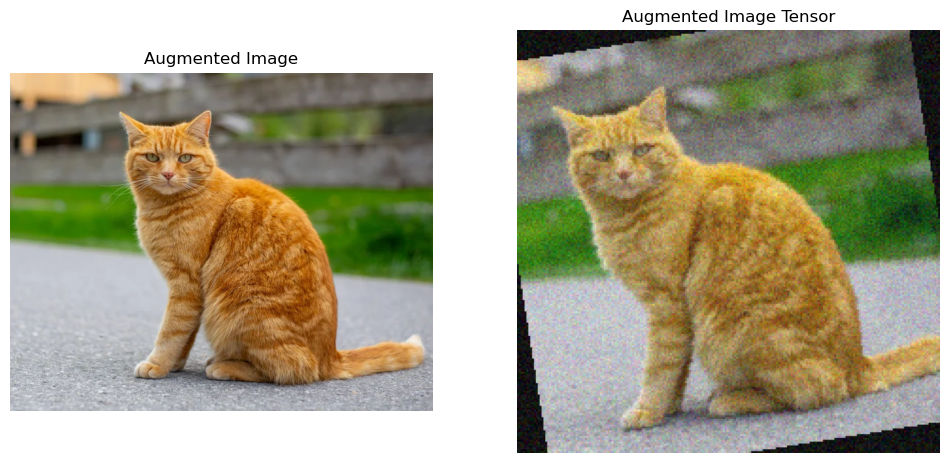

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import matplotlib.image as mpimg
from PIL import Image

# 1. 读取图片
img = mpimg.imread('/home/zhang/Documents/Programming/DataAnalysis_AI-Learning/3.DL_Learning/4. CNN/data/3542.jpg')
# 1.1 检查图片的尺寸和通道数
print("Original image type:", img.dtype)
print("Original image size:", img.shape)
print("Original image pixel range:", np.min(img), "to", np.max(img))

# 2. 定义各种augmentation方法
# 2.1 随机 resize + crop
resize_crop_transform = transforms.RandomResizedCrop(
    size=(224, 224),  # 输出尺寸
    scale=(0.8, 1.0),  # 随机裁剪的比例范围
    ratio=(0.9, 1.1)  # 随机裁剪的宽高比范围
)
# 2.2 随机 flip，注意这里只定义水平翻转，垂直翻转在自然图像中较少见
flip_transform = transforms.RandomHorizontalFlip(0.5)  # 50% 的概率水平翻转
# 2.3 随机 rotation 旋转
rotation_transform = transforms.RandomRotation(15) # 随机旋转 ±15 度
# 2.4 随机 color jitter 颜色抖动
color_jitter_transform = transforms.ColorJitter(
    brightness=0.2,  # 亮度调整范围
    contrast=0.2,    # 对比度调整范围
    saturation=0.2,  # 饱和度调整范围
    hue=0.1          # 色调调整范围
)

# 3. 依次应用增强方法，注意，这里的方法只能接受PIL Image作为输入，所以需要先将 numpy 数组转换为 PIL Image
img_PIL = Image.fromarray(img) # 将像素值从 [0, 1] 转换为 [0, 255] 并转换为 uint8 类型

img_PIL = resize_crop_transform(img_PIL)
img_PIL = flip_transform(img_PIL)
img_PIL = rotation_transform(img_PIL)
img_PIL = color_jitter_transform(img_PIL)

# 4. 将 PIL Image 转换为 Tensor
# 4.1 转换为tensor，并且修改dtype和归一化
# 注意，ToTensor() 会自动将像素值从 [0, 255] 转换为 [0.0, 1.0] 的浮点数，并且将通道维度放在前面，不需要手动调整 dtype 和归一化
to_tensor_transform = transforms.ToTensor() 
img_tensor = to_tensor_transform(img_PIL) # 转换为 tensor，形状为 (C, H, W)
# 4.2 检查转换后的 tensor 的尺寸和数值范围
print("Tensor image shape:", img_tensor.shape)
print("Tensor image pixel range:", torch.min(img_tensor).item(), "to", torch.max(img_tensor).item())


# 5. 添加高斯噪声
noise_transform = transforms.Lambda(
    lambda x: torch.clamp(x + torch.randn_like(x) * 0.05, 0.0, 1.0)
)
# 5.1 应用噪声变换
img_tensor = noise_transform(img_tensor) # 添加高斯噪声并且保持像素值在 [0.0, 1.0] 范围内
# 5.2 检查添加噪声后的 tensor 的数值范围
print("Noisy tensor image pixel range:", torch.min(img_tensor).item(), "to", torch.max(img_tensor).item())

# 6. 查看愿图像和增强后的图像,注意这里需要将增强后的图像转换回 numpy 格式以便显示
fig, axis = plt.subplots(1, 2, figsize=(12, 6))
# 6.1 显示原图像
axis[0].imshow(img)
axis[0].set_title("Original Image")
axis[0].axis('off')
# 6.2 显示增强后的图像
axis[1].imshow(img_tensor.permute(1, 2, 0).numpy())
axis[1].set_title("Augmented Image Tensor")
axis[1].axis('off')
plt.show()

##### 11.2 代码执行流程解释
这段代码的执行顺序如下：
* 先读取原始图像
    * 此时图像的数据类型为 Numpy
* 将图像转换为 PIL.Image
* 然后对 PIL.Image 依次执行：
    * 随机裁剪
    * 随机翻转
    * 随机旋转
    * 颜色抖动
* 再通过 ToTensor() 把图像转为 Tensor
    * 此时会自动进行
* 最后在 Tensor 上添加轻微噪声

📌 这样写的好处是非常直观，适合当前阶段学习。

你可以清楚看到：每一步增强到底是在什么时候做的。

##### 11.3 当前这个完整示例中要注意的点
这个例子里有一个很重要的顺序：
* 裁剪、翻转、旋转、颜色抖动
    * → 一般先对 PIL.Image 做
* ToTensor()
    * → 把图像转成 Tensor
* 加噪声
    * → 一般对 Tensor 做

所以不能随便把顺序打乱。

尤其是这里的：

`torch.randn_like(img)`

要求 img 必须已经是 Tensor。